In [4]:
import json
import pandas as pd

path = "/users/eleves-a/2023/allegra-maria-pia.boustany/llm-cross-eval/results/probe_sweep_results.jsonl"

rows = []
with open(path, "r", encoding="utf-8") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)
df.head(), df["control"].value_counts()

(      pooling  layer   val_acc  test_acc   val_bal  test_bal   val_auc  \
 0  last_token      1  0.666667  0.638333  0.628889  0.604444  0.663056   
 1  last_token      2  0.652500  0.644167  0.610556  0.605000  0.660022   
 2  last_token      3  0.644167  0.649167  0.621667  0.612778  0.667174   
 3  last_token      4  0.653333  0.661667  0.640000  0.618889  0.680300   
 4  last_token      5  0.656667  0.660000  0.633333  0.644444  0.692744   
 
    test_auc  val_top1  test_top1 control  
 0  0.646381  0.543333   0.433333    real  
 1  0.655044  0.473333   0.486667    real  
 2  0.650156  0.513333   0.480000    real  
 3  0.666007  0.570000   0.576667    real  
 4  0.686881  0.566667   0.553333    real  ,
 control
 real             72
 random_labels     1
 Name: count, dtype: int64)

In [5]:
real = df[df["control"] == "real"].copy()
ctrl = df[df["control"] == "random_labels"].copy()

print("Real rows:", len(real))
print("Control rows:", len(ctrl))
display(ctrl)  # should be 1 row (best setting only)


Real rows: 72
Control rows: 1


,pooling,layer,val_acc,test_acc,val_bal,test_bal,val_auc,test_auc,val_top1,test_top1,control
72,last_token,29,0.523333,0.518333,0.515556,0.492222,0.51363,0.500678,0.286667,0.233333,random_labels


In [6]:
best = real.sort_values("test_auc", ascending=False).iloc[0]
best


pooling      last_token
layer                29
val_acc        0.763333
test_acc         0.7925
val_bal        0.746667
test_bal       0.768333
val_auc         0.81517
test_auc       0.851678
val_top1       0.833333
test_top1      0.846667
control            real
Name: 28, dtype: object

In [7]:
real.sort_values("test_auc", ascending=False).head(10)[
    ["pooling","layer","test_auc","test_bal","test_top1","val_auc","val_bal","val_top1"]
]

,pooling,layer,test_auc,test_bal,test_top1,val_auc,val_bal,val_top1
28,last_token,29,0.851678,0.768333,0.846667,0.815170,0.746667,0.833333
24,last_token,25,0.848433,0.767778,0.823333,0.813011,0.738333,0.776667
25,last_token,26,0.847285,0.765556,0.816667,0.820581,0.750000,0.800000
29,last_token,30,0.845959,0.765556,0.830000,0.808574,0.720000,0.820000
26,last_token,27,0.845600,0.760000,0.820000,0.813748,0.738889,0.800000
22,last_token,23,0.845126,0.762222,0.853333,0.821993,0.730000,0.786667
27,last_token,28,0.844563,0.750000,0.826667,0.811022,0.738333,0.816667
30,last_token,31,0.844222,0.752778,0.810000,0.809604,0.739444,0.806667
23,last_token,24,0.842081,0.757222,0.813333,0.824178,0.756111,0.786667
31,last_token,32,0.837037,0.746667,0.803333,0.796478,0.715556,0.780000


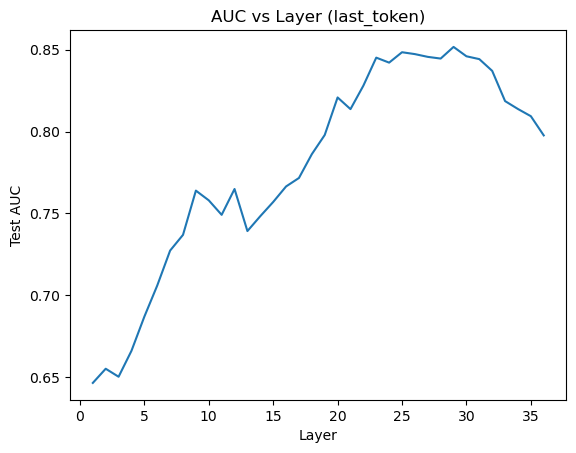

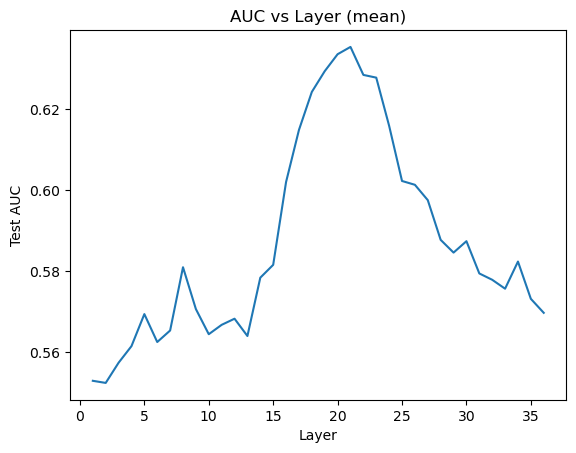

In [8]:
import matplotlib.pyplot as plt

for pooling in sorted(real["pooling"].unique()):
    sub = real[real["pooling"] == pooling].sort_values("layer")
    plt.figure()
    plt.plot(sub["layer"], sub["test_auc"])
    plt.xlabel("Layer")
    plt.ylabel("Test AUC")
    plt.title(f"AUC vs Layer ({pooling})")
    plt.show()

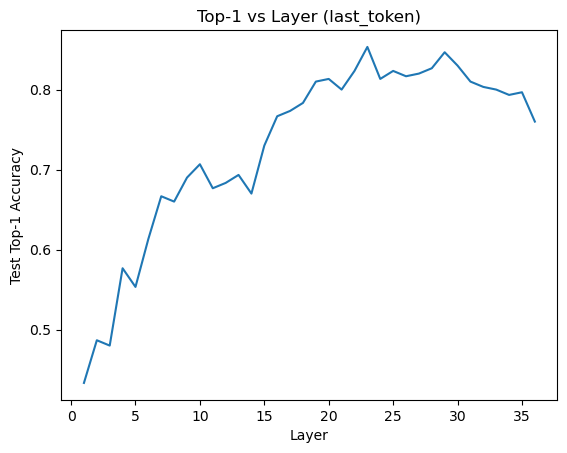

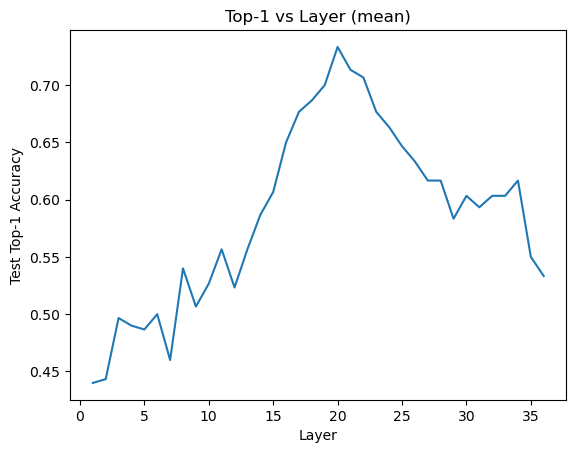

Top-1 baseline: 0.25


In [9]:
for pooling in sorted(real["pooling"].unique()):
    sub = real[real["pooling"] == pooling].sort_values("layer")
    plt.figure()
    plt.plot(sub["layer"], sub["test_top1"])
    plt.xlabel("Layer")
    plt.ylabel("Test Top-1 Accuracy")
    plt.title(f"Top-1 vs Layer ({pooling})")
    plt.show()

print("Top-1 baseline:", 0.25)


In [10]:
summary = (
    real.sort_values("test_auc", ascending=False)
        .groupby("pooling", as_index=False)
        .head(1)[["pooling","layer","test_auc","test_bal","test_top1"]]
)
summary

,pooling,layer,test_auc,test_bal,test_top1
28,last_token,29,0.851678,0.768333,0.846667
56,mean,21,0.635322,0.598333,0.713333


In [11]:
if len(ctrl) > 0:
    c = ctrl.iloc[0]
    print("Random-label control at best setting:")
    print("pooling:", c["pooling"], "layer:", c["layer"])
    print("test_auc:", c["test_auc"], "test_bal:", c["test_bal"], "test_top1:", c["test_top1"])
else:
    print("No control row found in df (did the script append it?).")

Random-label control at best setting:
pooling: last_token layer: 29
test_auc: 0.5006777777777778 test_bal: 0.4922222222222222 test_top1: 0.23333333333333334
